### imports

In [1]:
import pandas as pd
import numpy as np
import wfdb
import matplotlib.pyplot as plt
from preprocessing import *
import tensorflow as tf
import ast
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Bidirectional,
    LSTM,
    Dense
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model


### Dataset Info - PTB XL

21799 total 
(9514 - NORM; 
5469 - MI)


12 leads

5 classes

Sample duration - 10 sec

Freq - 100 or 500 Hz

partitioned into 10 folders. "all records of a particular patient were assigned to the same fold"

### Loading dataset

In [2]:
tf.config.list_physical_devices("GPU")

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
#path_metadata = "C:\\Users\\Larissa\\bsi\\IC2025\\datasets\\ptbxl\\ptbxl_database.csv"
path_metadata = "C:\\Users\\Larissa\\Downloads\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\ptbxl_database.csv"
sampling_rate = 100 #500
#main_path = "C:\\Users\\Larissa\\bsi\\IC2025\\datasets\\ptbxl\\" #\\records"+str(sampling_rate)
main_path = "C:\\Users\\Larissa\\Downloads\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\"

In [12]:
#loadidng metadata
metadata_all_df = pd.read_csv(path_metadata, index_col='ecg_id')
metadata_all_df.scp_codes = metadata_all_df.scp_codes.apply(lambda x: ast.literal_eval(x))

In [13]:
#loading raw signal data
ecg_data = load_raw_data(metadata_all_df, sampling_rate, main_path)

In [14]:
print(ecg_data[1].shape)
print("12 leads & 1000 points from each lead(?)")

(1000, 12)
12 leads & 1000 points from each lead(?)


In [ ]:
# Load scp_statements.csv for diagnostic aggregation

def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

agg_df = pd.read_csv(main_path+'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

In [16]:
def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))


In [17]:
# Apply diagnostic superclass
metadata_all_df['diagnostic_superclass'] = metadata_all_df.scp_codes.apply(aggregate_diagnostic)

##### visualizing a few signals

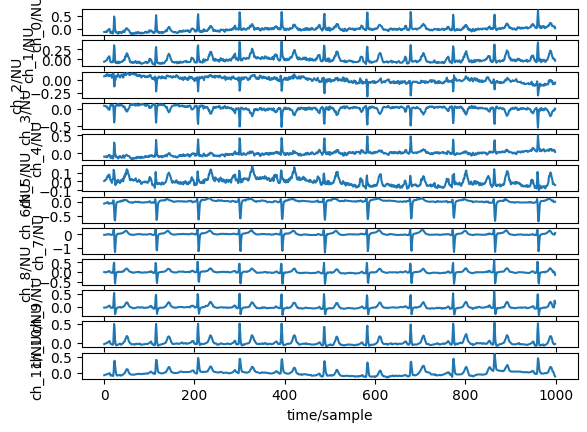

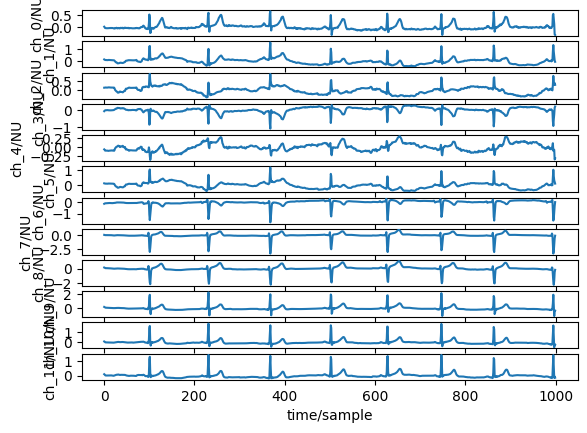

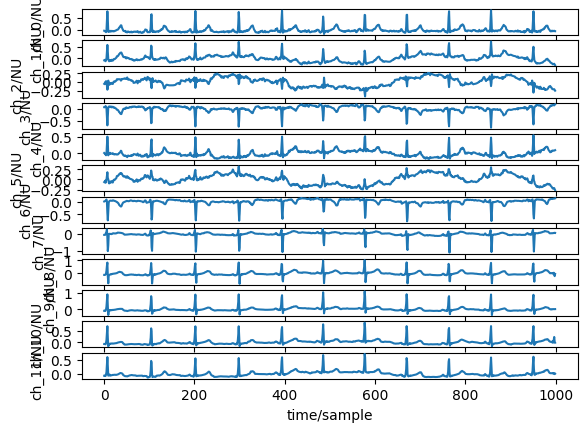

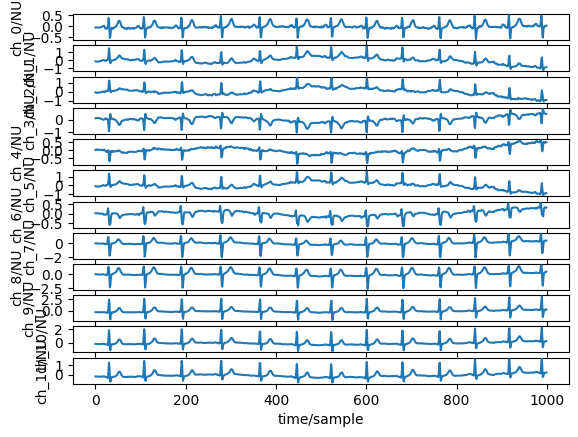

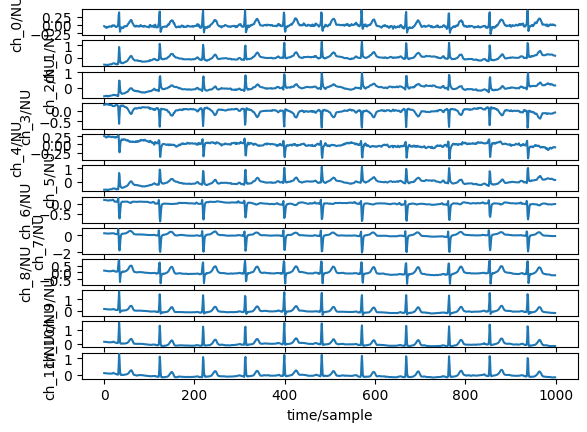

In [ ]:
for i in range(5):
    wfdb.plot.plot_items(signal=ecg_data[i])


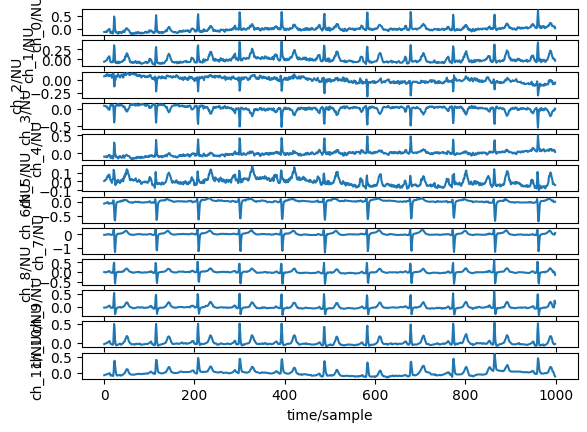

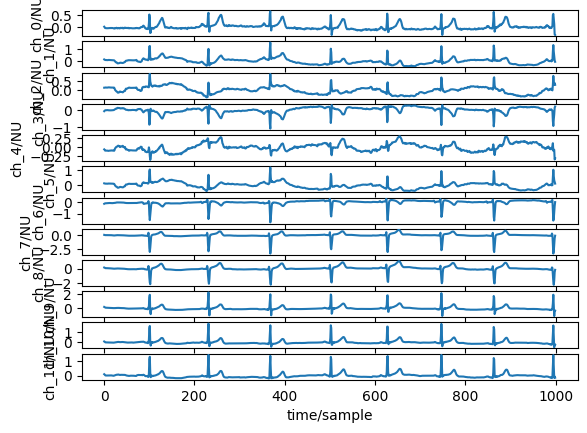

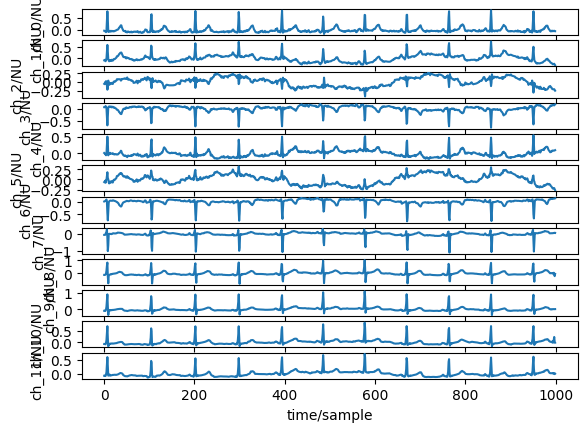

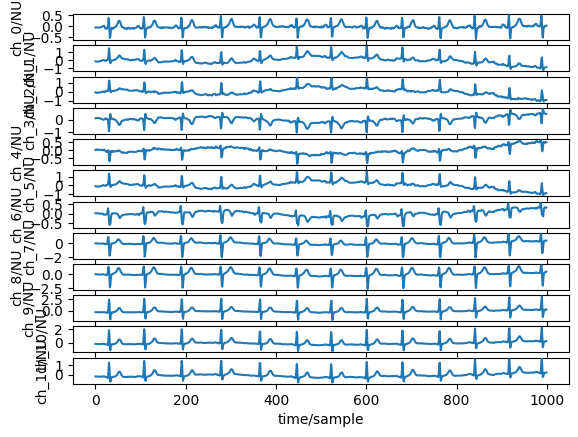

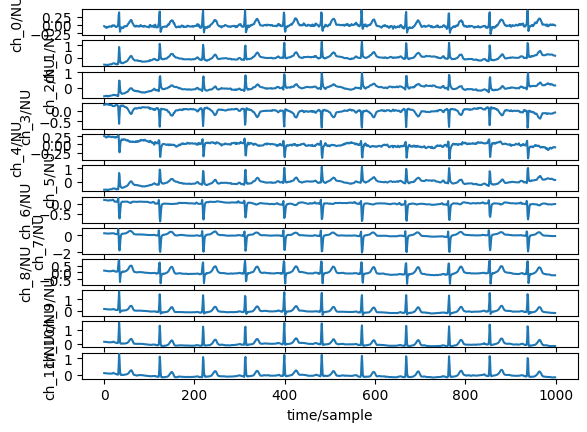

In [13]:
#loading 5 normal ecgs
for i in range(5):
    wfdb.plot.plot_items(signal=X_norm[i])


### Preprocessing


### splitting

In [18]:
import random

def split_ds(x, y, train_folds=7, val_folds=2, test_folds=1):

    folds = list(range(1, y["strat_fold"].max() + 1))
    random.shuffle(folds)

    train = folds[:train_folds]

    val = folds[
        train_folds :
        train_folds + val_folds
    ]

    test = folds[
        train_folds + val_folds :
    ]

    train_mask = y["strat_fold"].isin(train)
    val_mask = y["strat_fold"].isin(val)
    test_mask = y["strat_fold"].isin(test)

    return (
        (x[train_mask], y[train_mask]),
        (x[val_mask], y[val_mask]),
        (x[test_mask], y[test_mask]),
    )

In [19]:
mask = metadata_all_df["diagnostic_superclass"].isin([["NORM"], ["MI"]])

metadata = metadata_all_df[mask].copy()
X = ecg_data[mask]

metadata["label"] = (
    metadata["diagnostic_superclass"].apply(lambda x: x == ["MI"])
).astype(int)

train, val, test = split_ds(X, metadata)

raw_xtrain, ytrain = train
raw_xval, yval = val
raw_xtest, ytest = test

processed_xtrain = np.array([
    preprocess_ecg(ecg)
    for ecg in raw_xtrain
])

processed_xval = np.array([
    preprocess_ecg(ecg)
    for ecg in raw_xval
])

processed_xtest = np.array([
    preprocess_ecg(ecg)
    for ecg in raw_xtest
])

X_train, X_val, X_test, scaler = standardize_signals(
    processed_xtrain,
    processed_xval,
    processed_xtest
)

In [20]:
yval

,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr,diagnostic_superclass,label
ecg_id,,,,,,,,,,,,,,,,,,,,,
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr,[NORM],0
7,16193.0,54.0,0,NaN,83.0,2.0,0.0,CS-12 E,1984-11-28 13:32:22,"sinusrhythmus linkstyp t abnormal, wahrscheinl...",...,NaN,NaN,NaN,NaN,NaN,7,records100/00000/00007_lr,records500/00000/00007_hr,[NORM],0
11,11243.0,20.0,1,NaN,57.0,2.0,0.0,CS-12 E,1984-12-16 14:20:39,sinus arrhythmie sonst normales ekg,...,", I-AVL,",NaN,NaN,NaN,NaN,5,records100/00000/00011_lr,records500/00000/00011_hr,[NORM],0
14,12925.0,19.0,1,NaN,58.0,2.0,0.0,CS-12 E,1985-01-10 11:45:19,sinusrhythmus normales ekg,...,NaN,NaN,NaN,NaN,NaN,7,records100/00000/00014_lr,records500/00000/00014_hr,[NORM],0
19,11116.0,20.0,0,NaN,85.0,2.0,0.0,CS-12 E,1985-01-23 11:23:00,sinusrhythmus p-verbreiterung,...,NaN,NaN,NaN,NaN,NaN,7,records100/00000/00019_lr,records500/00000/00019_hr,[NORM],0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21802,10457.0,73.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-02-07 16:32:24,sinusrhythmus lagetyp normal normales ekg 4.46...,...,", I-AVR,",NaN,NaN,NaN,NaN,7,records100/21000/21802_lr,records500/21000/21802_hr,[NORM],0
21811,12934.0,75.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-02-19 16:33:28,sinusrhythmus lagetyp normal qrs(t) abnorm ...,...,", I-AVR,",NaN,NaN,NaN,NaN,7,records100/21000/21811_lr,records500/21000/21811_hr,[MI],1
21813,10205.0,75.0,1,NaN,NaN,1.0,2.0,AT-60 3,2001-02-24 06:43:17,sinusrhythmus lagetyp normal normales ekg 4.46...,...,", I-AVR,",NaN,NaN,NaN,NaN,7,records100/21000/21813_lr,records500/21000/21813_hr,[NORM],0


## modelo

In [24]:
def create_model():
    model = Sequential([

        Input(shape=(1000, 12)),

        Bidirectional(
            LSTM(
                units=32,
                return_sequences=True
            )
        ),

        Bidirectional(
            LSTM(
                units=16,
                return_sequences=True
            )
        ),

        Bidirectional(
            LSTM(
                units=4,
                return_sequences=False
            )
        ),

        Dense(
            32,
            activation="relu"
        ),

        Dense(
            16,
            activation="relu"
        ),

        Dense(
            1,
            activation="sigmoid"
        )
    ])


    return model

In [ ]:
model = create_model()

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")]
)

model.summary()

## callbacks ##
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

model_path = "..\models"
checkpoint = ModelCheckpoint(
    model_path,
    monitor="val_loss",
    verbose=1,
    save_best_only=True,
    save_weights_only=False,
    mode="auto",
    save_freq="epoch",
    initial_value_threshold=None,
)

# training
history = model.fit(
    X_train,
    ytrain['label'],
    validation_data=(X_val, yval['label']),
    epochs=50,
    batch_size=128,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

AttributeError: module 'keras.api._v2.keras.metrics' has no attribute 'F1Score'

In [ ]:
model = load_model("..\models")

results = model.evaluate(
    X_test,
    ytest['label'],
    verbose=1
)

print("\nResultados:")
for nome, valor in zip(model.metrics_names, results):
    print(f"{nome}: {valor:.4f}")

In [ ]:
loss, acc, precis, recall, auc = model.evaluate(X_test, ytest['label'], batch_size=128)

13/13 [==============================] - 14s 657ms/step - loss: 0.1709 - accuracy: 0.9427 - precision: 0.8971 - recall: 0.7991 - auc: 0.9655


[0.17088733613491058,
 0.9427350163459778,
 0.8970588445663452,
 0.7991266250610352,
 0.9654552936553955]

In [ ]:
#############################
# PLOTAR MATRIZ DE CONFUSAO
#PRINTAR RESULTADOS (acc, precisao, recall, auc FALTA COLOCAR F1 E ESPECIFICIDADE)
# anotar hiperparametros
# plotar loss e acc ao longo do treinamento

# baseline -> hyperparameter tuning -> melhor modelo -> data augmentation -> modelo final


In [26]:
#hiperparametros
LR = 0.001
BATCH_SIZE = 96
EPOCHS = 50
AUGMENTATION = False

In [32]:
result_df = pd.DataFrame({"model":[],
                          "aumento de dados":[],
                          "acc": [],
                          "recall": [],
                          "f1": [],
                          "auc":[],
                          "batchsize": [],
                          "epochs": [],
                          "lr": []})

In [ ]:
result_df.loc[len(result_df)] = ["baseline (cnn + bilstm)", AUGMENTATION, acc, recall, None, auc, BATCH_SIZE, 36, LR]

In [34]:
result_df

,model,aumento de dados,acc,recall,f1,auc,batchsize,epochs,lr
0,baseline (cnn + bilstm),False,0.942735,0.799127,None,0.965455,96,36,0.001


### tuning hyperparameters - learning rate and batchsize

In [22]:
## callbacks ##
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

In [ ]:
model_path = "..\\models"

learning_rates = [1e-4, 1e-3, 1e-2]
batch_sizes = [32, 64, 96]

result_models = []

for lr in learning_rates:
    for batch_size in batch_sizes:
        print(f"\nTestando learning rate = {lr}")
        print(f"\nTestando batch size = {batch_size}")

        model = create_model()
        model.summary()

        model_file_path = model_path + f"\\model_{lr}_{batch_size}.keras"
        checkpoint = ModelCheckpoint(
        model_file_path,
        monitor="val_loss",
        verbose=1,
        save_best_only=True,
        save_weights_only=False,
        mode="auto",
        save_freq="epoch",
        initial_value_threshold=None,
    )
        
        ## compilation ##
        model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")])

        ## training ##
        history = model.fit(
            X_train,
            ytrain['label'],
            validation_data=(X_val, yval['label']),
            epochs=50,
            batch_size=batch_size,
            callbacks=[early_stop, checkpoint],
            verbose=1
        )

        result_models.append([lr, batch_size, history])
        best_val_auc = max(history.history["val_auc"])
        best_val_loss = min(history.history["val_loss"])


    print("ACABOOOOOO EEEEEEEEEEEEEEEEEE\nagr vc precisa verificar o desempenho de cada um deles")


Testando learning rate = 0.0001

Testando batch size = 32
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_3 (Bidirectio  (None, 1000, 64)         11520     
 nal)                                                            
                                                                 
 bidirectional_4 (Bidirectio  (None, 1000, 32)         10368     
 nal)                                                            
                                                                 
 bidirectional_5 (Bidirectio  (None, 8)                1184      
 nal)                                                            
                                                                 
 dense_3 (Dense)             (None, 32)                288       
                                                                 
 dense_4 (Dense)             (None, 16)                528   

In [39]:
for i in result_models:
    print(i[2].history.keys()) 

dict_keys(['loss', 'accuracy', 'precision', 'recall', 'auc', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_auc'])
dict_keys(['loss', 'accuracy', 'precision', 'recall', 'auc', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_auc'])
dict_keys(['loss', 'accuracy', 'precision', 'recall', 'auc', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_auc'])
dict_keys(['loss', 'accuracy', 'precision', 'recall', 'auc', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_auc'])
dict_keys(['loss', 'accuracy', 'precision', 'recall', 'auc', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_auc'])
dict_keys(['loss', 'accuracy', 'precision', 'recall', 'auc', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_auc'])
dict_keys(['loss', 'accuracy', 'precision', 'recall', 'auc', 'val_loss', 'val_accuracy', 'val_precision', 'val_recall', 'val_auc'])
dict_keys(['loss', 'accuracy', 'precision', 'recall', 'auc', 'val_loss', 'va

In [43]:
for i in result_models:
    print((i[2].history["val_auc"][-1]))
    print((i[2].history["val_loss"][-1]))
    print((i[2].history["val_accuracy"][-1]))
    print()
    

0.9317724108695984
0.25241634249687195
0.8977566957473755

0.93662428855896
0.2523534893989563
0.9089732766151428

0.9191707968711853
0.26925161480903625
0.8973252773284912

0.9621472358703613
0.21162769198417664
0.918464183807373

0.9589646458625793
0.31837156414985657
0.8572044968605042

0.9536018967628479
0.22441737353801727
0.9180327653884888

0.9614768028259277
0.19637952744960785
0.9214840531349182

0.9525262713432312
0.2276238203048706
0.9227782487869263

0.955918550491333
0.22006456553936005
0.9232096672058105



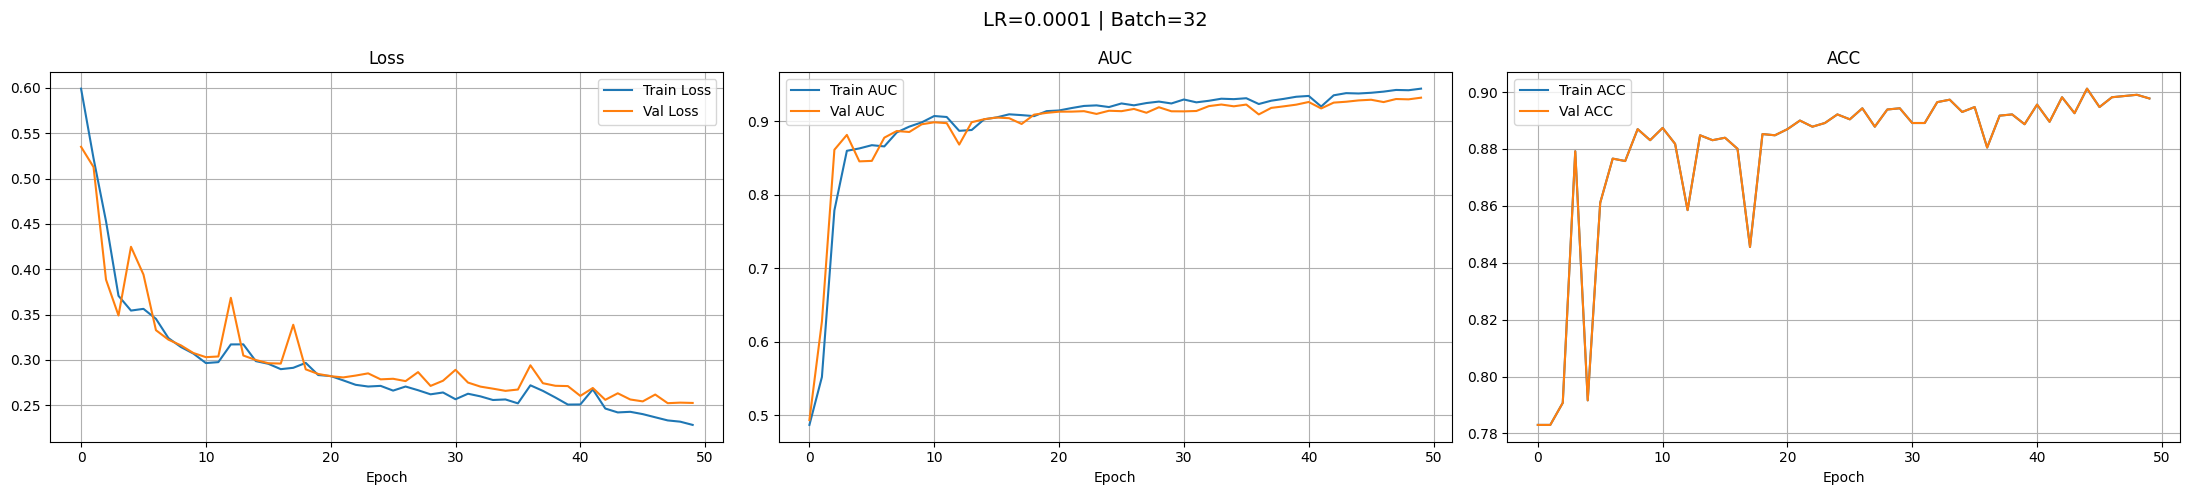

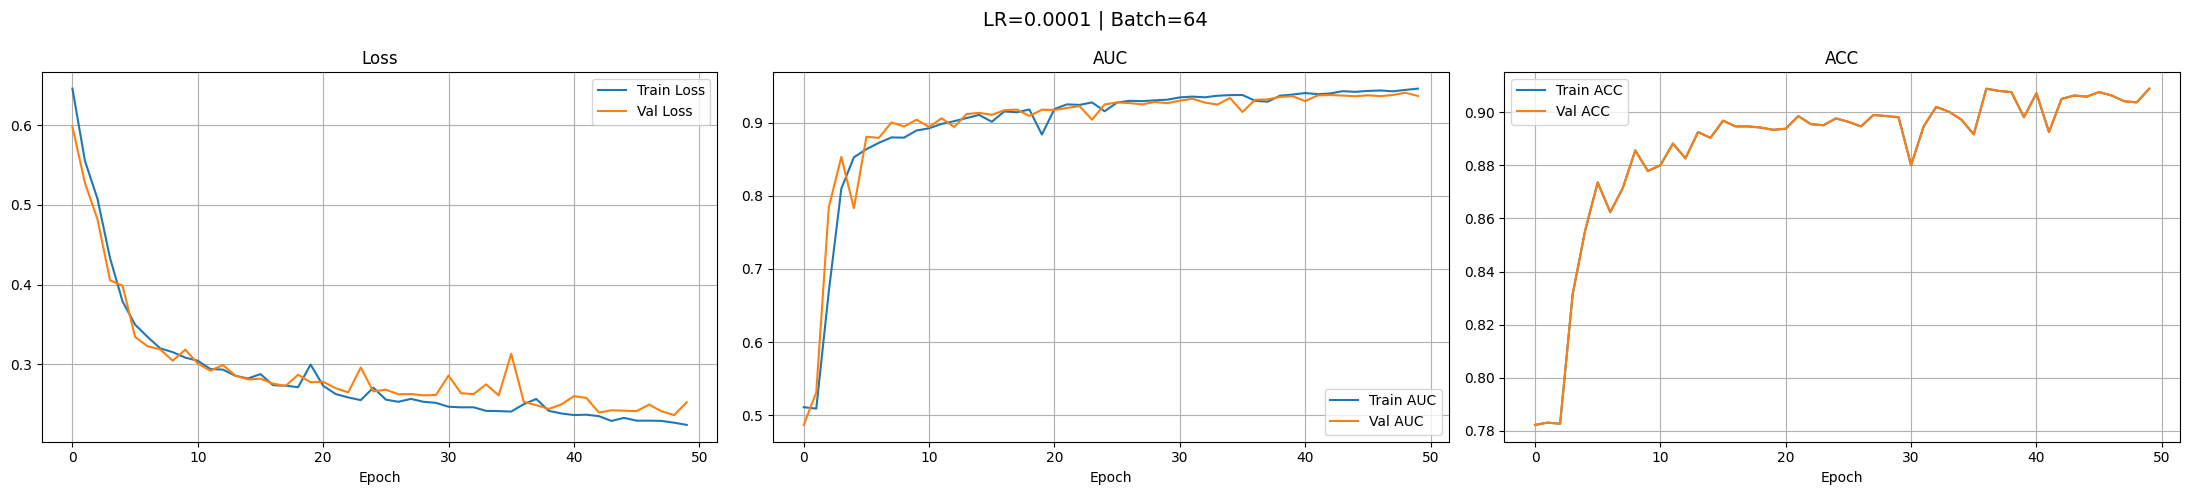

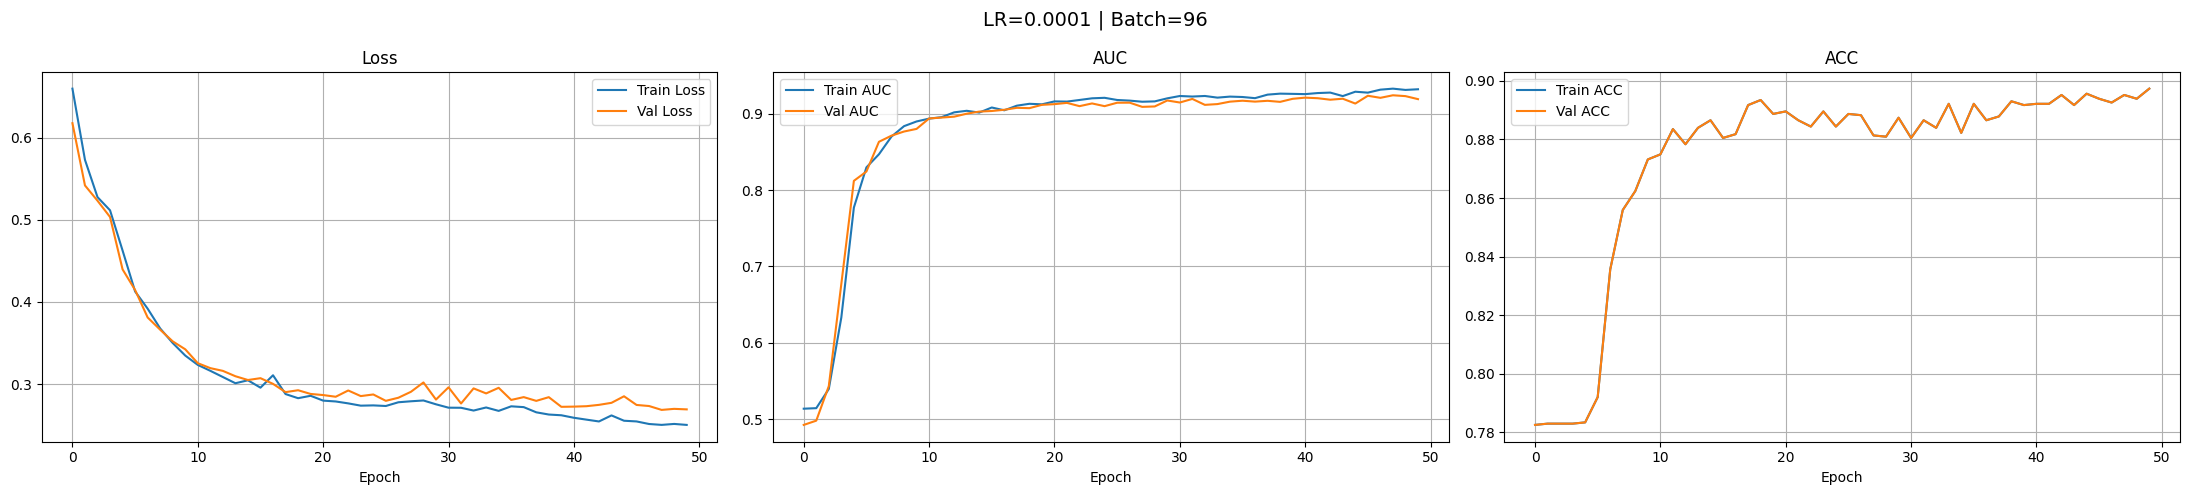

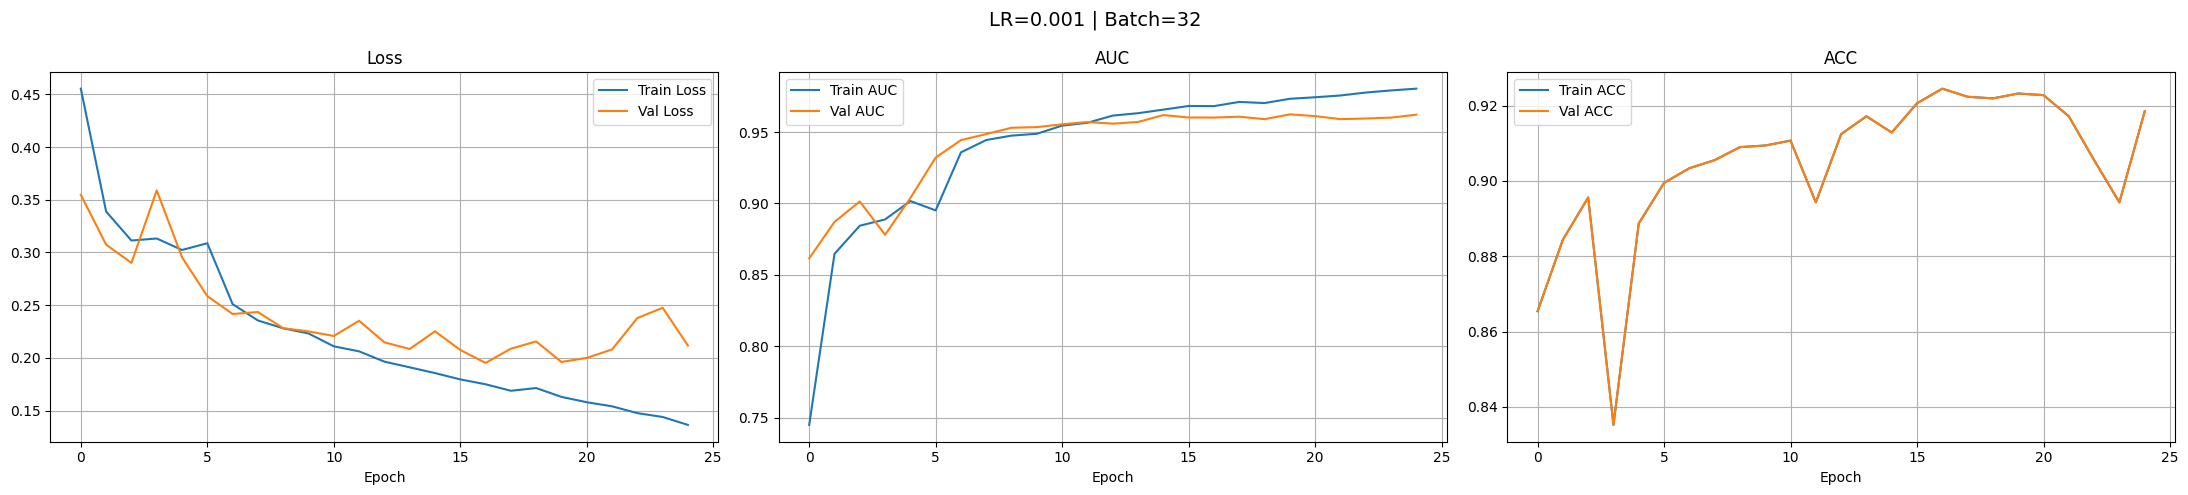

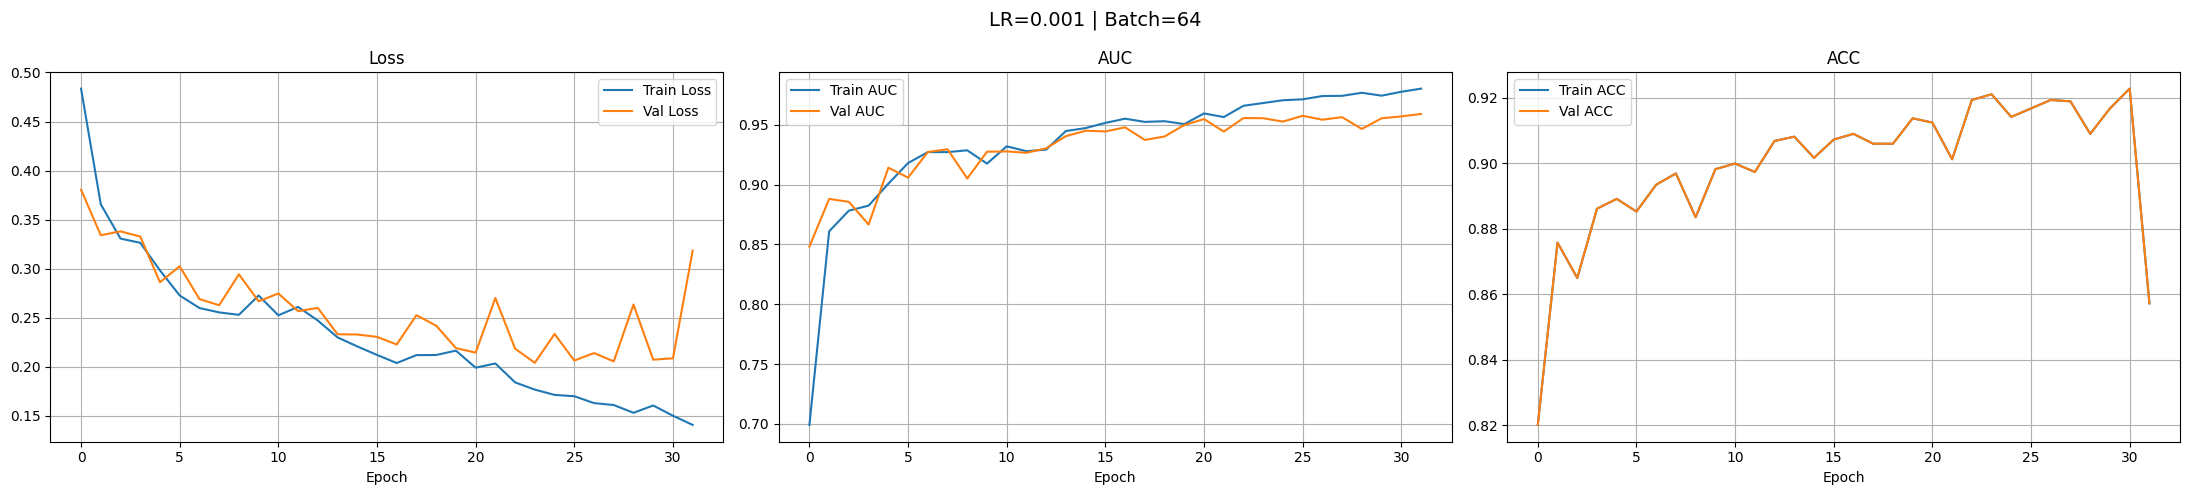

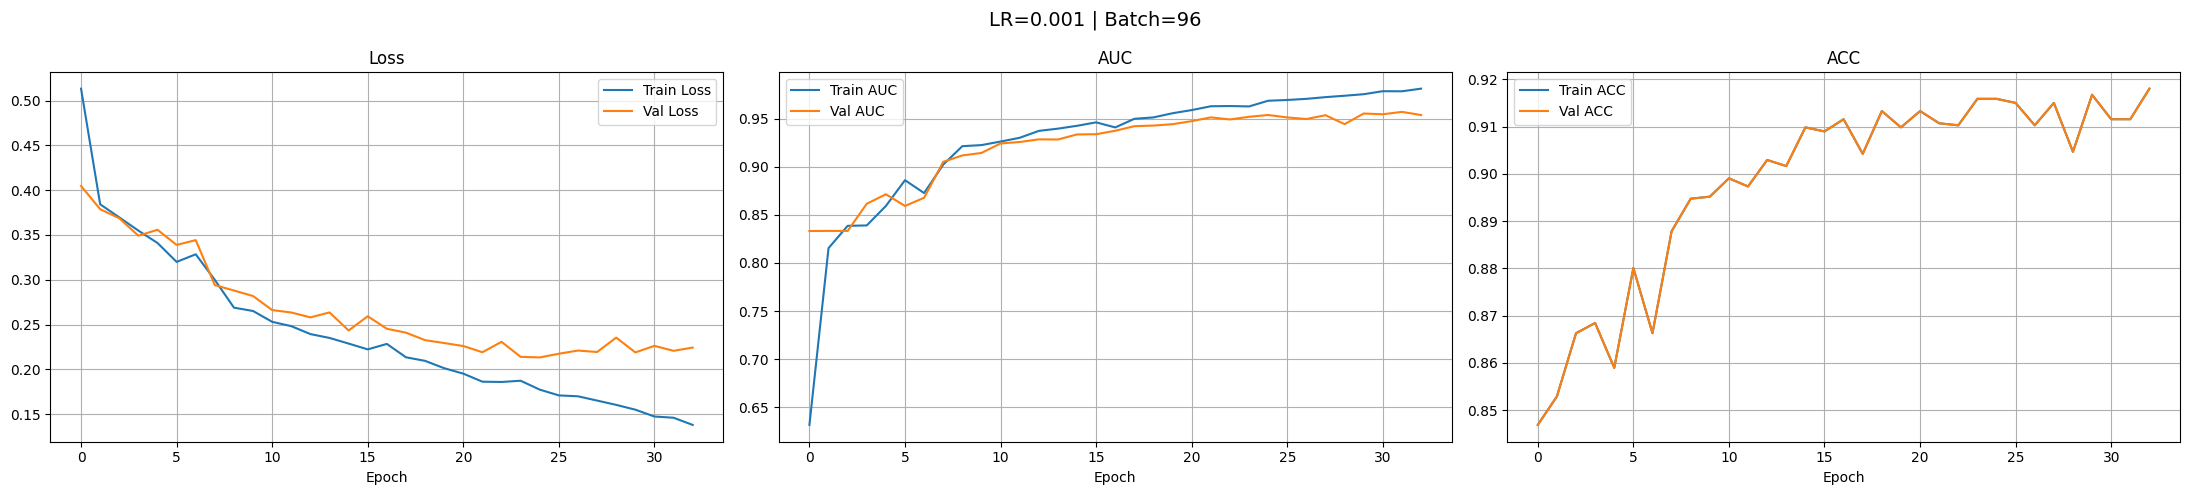

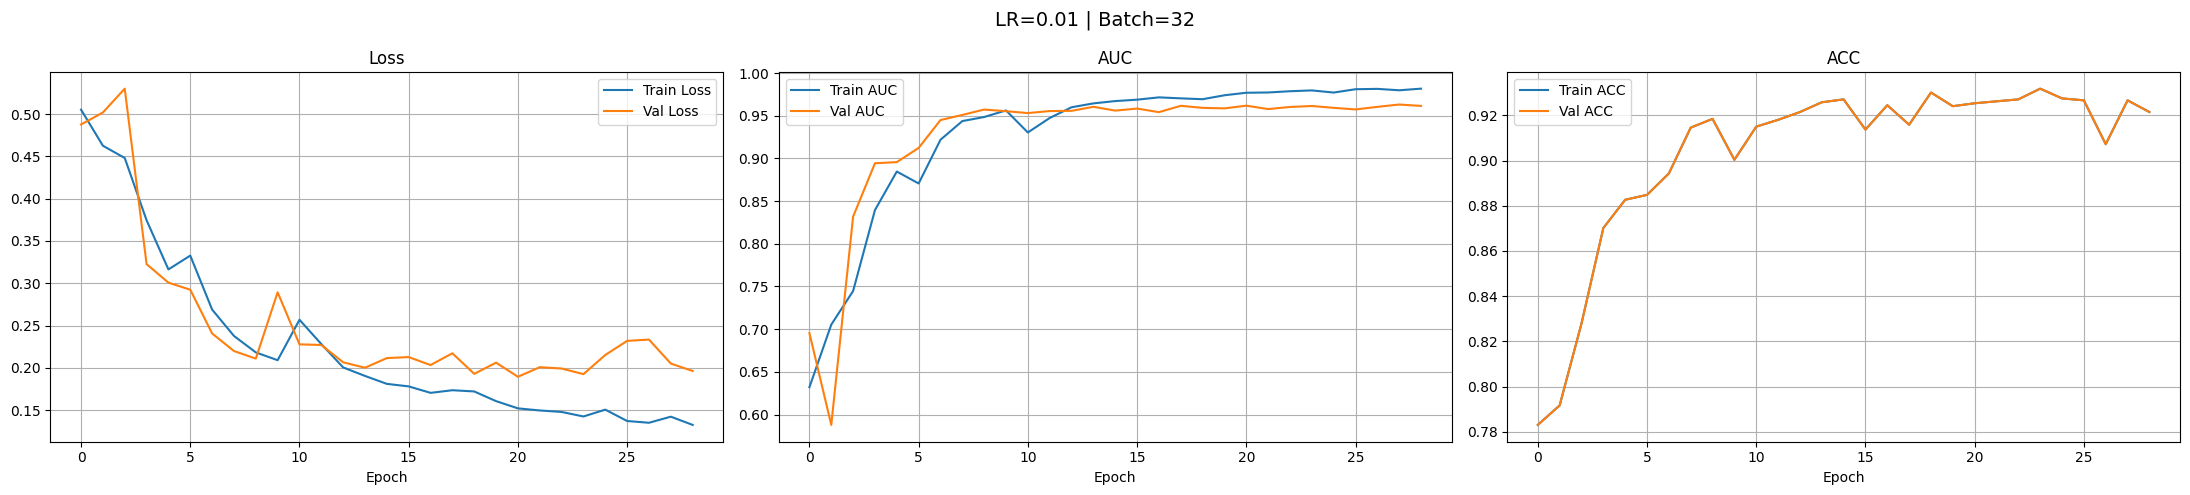

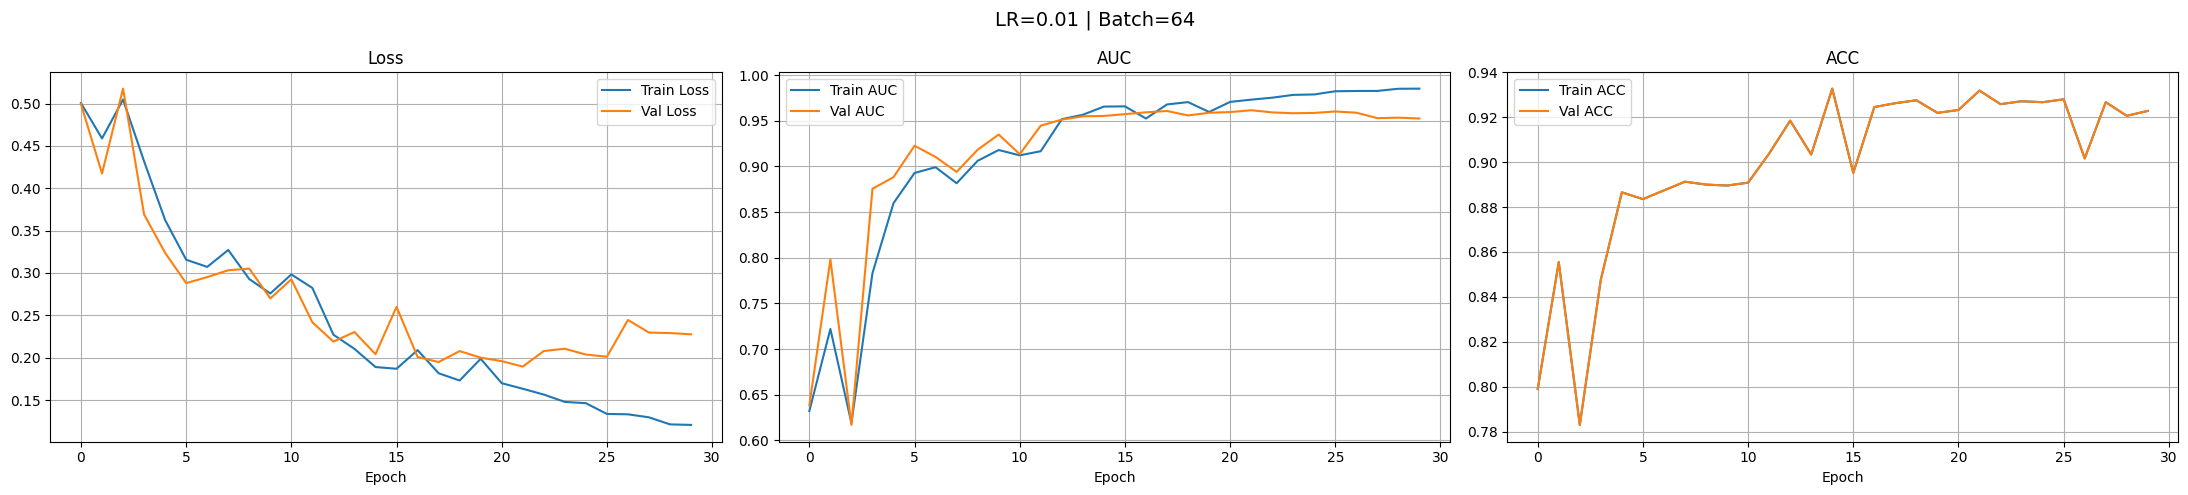

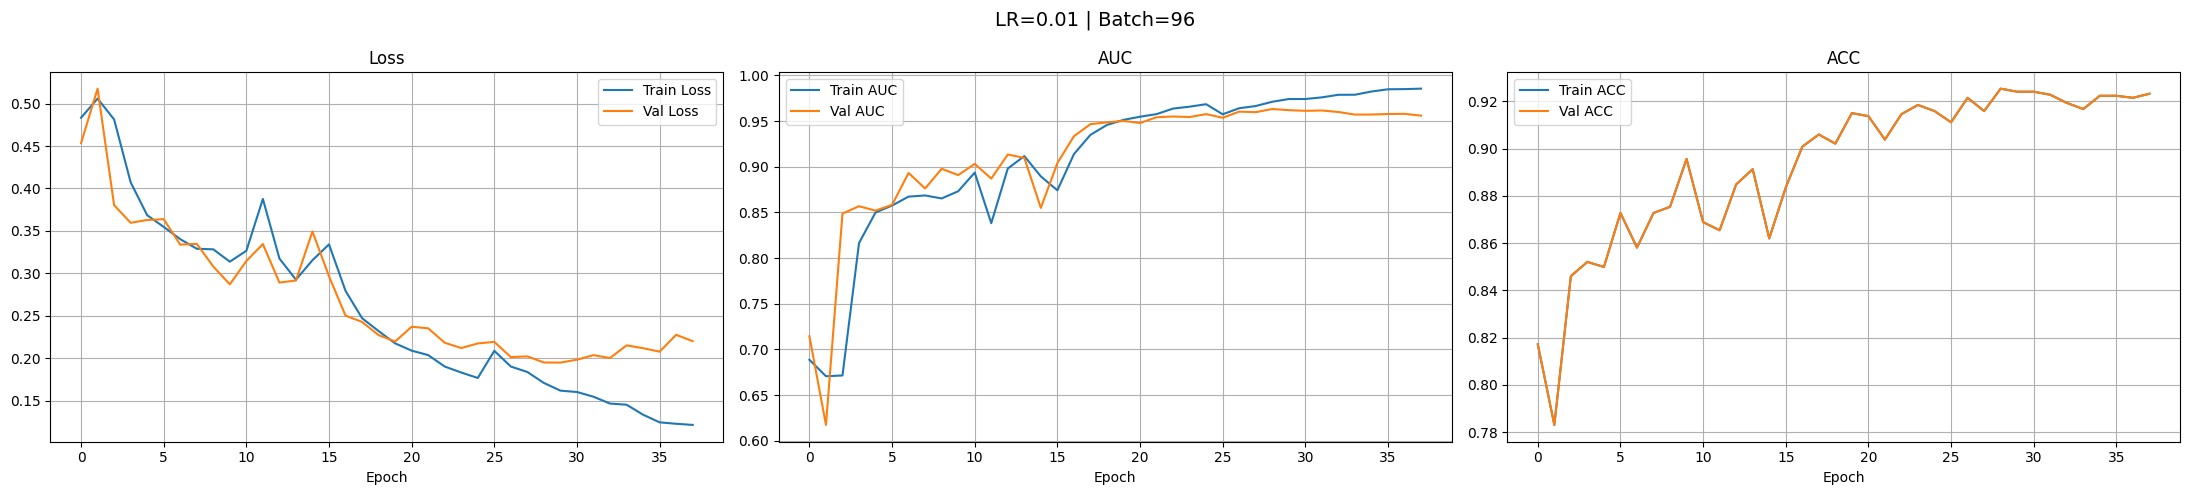

In [47]:
import matplotlib.pyplot as plt

def plot_history(history, lr, batch_size):
    fig, axes = plt.subplots(1, 3, figsize=(22, 5))
    fig.suptitle(f"LR={lr} | Batch={batch_size}", fontsize=14)

    # Loss
    axes[0].plot(history.history["loss"], label="Train Loss")
    axes[0].plot(history.history["val_loss"], label="Val Loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(True)

    # AUC (ou troca por "accuracy" se preferir)
    axes[1].plot(history.history["auc"], label="Train AUC")
    axes[1].plot(history.history["val_auc"], label="Val AUC")
    axes[1].set_title("AUC")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(True)

    # acc
    axes[2].plot(history.history["val_accuracy"], label="Train ACC")
    axes[2].plot(history.history["val_accuracy"], label="Val ACC")
    axes[2].set_title("ACC")
    axes[2].set_xlabel("Epoch")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

# Plotar todos
for lr, batch_size, history in result_models:
    plot_history(history, lr, batch_size)

In [2]:
model_01 = tf.keras.models.load_model(
    "../models/model_0.01_32.keras"
)

model_001 = tf.keras.models.load_model(
    "../models/model_0.001_32.keras"
)

'''results_01 = model_01.evaluate(
    X_test,
    ytest["label"].to_numpy(),
    verbose=1
)

results_001 = model_001.evaluate(
    X_test,
    ytest["label"].to_numpy(),
    verbose=1
)'''

'results_01 = model_01.evaluate(\n    X_test,\n    ytest["label"].to_numpy(),\n    verbose=1\n)\n\nresults_001 = model_001.evaluate(\n    X_test,\n    ytest["label"].to_numpy(),\n    verbose=1\n)'

In [ ]:
'''
model_01
val:
0.9614768028259277 - auc
0.19637952744960785 - loss
0.9214840531349182 - acc
test
37/37 [==============================] - 8s 177ms/step - loss: 0.2121 - accuracy: 0.9211 - precision: 0.8739 - recall: 0.7732 - auc: 0.9553



model_001
val:
0.9621472358703613 - auc
0.21162769198417664 - loss
0.918464183807373 - acc
test
37/37 [==============================] - 8s 183ms/step - loss: 0.2029 - accuracy: 0.9263 - precision: 0.9071 - recall: 0.7621 - auc: 0.9625
'''

### using data augmentation